In [29]:
from pathlib import Path
import numpy as np
import pandas as pd

In [30]:
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"

residue_path = PROCESSED_DIR / "chi1_residue_level_dataset_with_backbone.csv"

residue_df = pd.read_csv(residue_path)

residue_df.head()

/var/folders/j3/qr5mg5rj55j5lf7yh978r__80000gn/T/ipykernel_5807/2338238424.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  residue_df = pd.read_csv(residue_path)


,pdb_id,chain_id,residue_number,insertion_code,resname,chi1_angle,chi1_bin_10deg,target_mask,phi_angle,psi_angle,...,ca_y,ca_z,has_ca,polarity_group,hydropathy_group,volume_group,chemical_group,physicochemical_group,charge_group,hydrogen_donor_acceptor_group
0,2BO5,A,1,NaN,PHE,267.667646,26,1,NaN,181.918425,...,12.444,24.544001,1,nonpolar,hydrophobic,large,aromatic,aromatic,neutral,none
1,2BO5,A,2,NaN,ALA,NaN,-100,0,60.562806,33.116558,...,11.484,21.757999,1,nonpolar,hydrophobic,small,aliphatic,nonpolar_aliphatic,neutral,none
2,2BO5,A,3,NaN,LYS,270.463347,27,1,299.348529,285.420907,...,9.539,24.302000,1,polar,hydrophilic,large,basic,positive,positive,donor
3,2BO5,A,4,NaN,LEU,314.589093,31,1,61.046673,156.017583,...,9.970,22.927000,1,nonpolar,hydrophobic,large,aliphatic,nonpolar_aliphatic,neutral,none
4,2BO5,A,5,NaN,VAL,286.087049,28,1,248.450014,326.412570,...,7.605,23.750000,1,nonpolar,hydrophobic,medium,aliphatic,nonpolar_aliphatic,neutral,none


In [31]:

residue_path = PROCESSED_DIR / "chi1_residue_level_dataset_with_backbone.csv"

residue_df = pd.read_csv(residue_path)

SPLIT_DIR = DATA_DIR / "splits"

train_pdb_ids = set(pd.read_csv(SPLIT_DIR / "train_pdb_ids.csv")["pdb_id"])
val_pdb_ids = set(pd.read_csv(SPLIT_DIR / "val_pdb_ids.csv")["pdb_id"])
test_pdb_ids = set(pd.read_csv(SPLIT_DIR / "test_pdb_ids.csv")["pdb_id"])

train_residue_df = residue_df[residue_df["pdb_id"].isin(train_pdb_ids)].copy()
val_residue_df = residue_df[residue_df["pdb_id"].isin(val_pdb_ids)].copy()
test_residue_df = residue_df[residue_df["pdb_id"].isin(test_pdb_ids)].copy()

print(train_residue_df.shape)
print(val_residue_df.shape)
print(test_residue_df.shape)

/var/folders/j3/qr5mg5rj55j5lf7yh978r__80000gn/T/ipykernel_5807/601228350.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  residue_df = pd.read_csv(residue_path)


(929004, 27)
(113997, 27)
(118229, 27)


In [32]:
ID_COLUMNS = [
    "pdb_id",
    "chain_id",
    "residue_number",
    "insertion_code",
]

FEATURE_COLUMNS = [
    "resname",
    "polarity_group",
    "hydropathy_group",
    "volume_group",
    "chemical_group",
    "physicochemical_group",
    "charge_group",
    "hydrogen_donor_acceptor_group",
]

TARGET_COLUMN = "chi1_bin_10deg"
MASK_COLUMN = "target_mask"

WINDOW_SIZE = 65
CONTEXT_RADIUS = WINDOW_SIZE // 2

PAD_TOKEN = "PAD"
IGNORE_INDEX = -100

NUMERIC_FEATURE_COLUMNS = [
    "phi_sin",
    "phi_cos",
    "psi_sin",
    "psi_cos",
    "has_phi",
    "has_psi",
    "relative_position",
]

DISTANCE_NORMALIZATION = 30.0

In [33]:
def prepare_residue_df_for_windows(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["pdb_id"] = df["pdb_id"].astype(str).str.upper()
    df["chain_id"] = df["chain_id"].astype(str)

    df["residue_number"] = df["residue_number"].astype(int)

    df["insertion_code"] = (
        df["insertion_code"]
        .fillna("")
        .astype(str)
        .replace("nan", "")
    )

    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)
    df[MASK_COLUMN] = df[MASK_COLUMN].astype(int)

    df = df.sort_values(
        ["pdb_id", "chain_id", "residue_number", "insertion_code"]
    ).reset_index(drop=True)

    return df

In [34]:
residue_df = prepare_residue_df_for_windows(residue_df)

residue_df.head()

,pdb_id,chain_id,residue_number,insertion_code,resname,chi1_angle,chi1_bin_10deg,target_mask,phi_angle,psi_angle,...,ca_y,ca_z,has_ca,polarity_group,hydropathy_group,volume_group,chemical_group,physicochemical_group,charge_group,hydrogen_donor_acceptor_group
0,133L,A,1,,LYS,72.602035,7,1,NaN,151.664947,...,20.433001,21.160000,1,polar,hydrophilic,large,basic,positive,positive,donor
1,133L,A,2,,VAL,184.764731,18,1,254.529890,114.762469,...,19.736000,18.659000,1,nonpolar,hydrophobic,medium,aliphatic,nonpolar_aliphatic,neutral,none
2,133L,A,3,,PHE,279.004006,27,1,286.350988,150.684206,...,22.340000,18.976999,1,nonpolar,hydrophobic,large,aromatic,aromatic,neutral,none
3,133L,A,4,,GLU,284.236970,28,1,273.982337,158.728892,...,23.539000,16.051001,1,polar,hydrophilic,large,acidic,negative,negative,acceptor
4,133L,A,5,,ARG,188.255005,18,1,305.536639,301.401648,...,23.135000,16.552000,1,polar,hydrophilic,large,basic,positive,positive,donor


In [35]:
residue_df[
    [
        "resname",
        "chi1_bin_10deg",
        "target_mask",
        "phi_sin",
        "phi_cos",
        "psi_sin",
        "psi_cos",
        "has_phi",
        "has_psi",
        "ca_x",
        "ca_y",
        "ca_z",
        "has_ca",
    ]
].head()

,resname,chi1_bin_10deg,target_mask,phi_sin,phi_cos,psi_sin,psi_cos,has_phi,has_psi,ca_x,ca_y,ca_z,has_ca
0,LYS,7,1,0.000000,0.000000,0.474627,-0.880187,0,1,1.782,20.433001,21.160000,1
1,VAL,18,1,-0.963770,-0.266736,0.908052,-0.418857,1,1,4.609,19.736000,18.659000,1
2,PHE,27,1,-0.959555,0.281521,0.489623,-0.871934,1,1,7.321,22.340000,18.976999,1
3,GLU,28,1,-0.997586,0.069449,0.362781,-0.931874,1,1,9.297,23.539000,16.051001,1
4,ARG,18,1,-0.813744,0.581223,-0.853536,0.521034,1,1,13.067,23.135000,16.552000,1


In [36]:
# windows_65 = build_windows_65(residue_df)

# print("Number of windows:", len(windows_65))
# print("Example keys:", windows_65[0].keys())

residue_df.to_csv(
    PROCESSED_DIR / "chi1_residue_level_dataset_with_backbone_prepared.csv",
    index=False,
)

print("Saved prepared residue-level dataset.")

Saved prepared residue-level dataset.


In [37]:
PAD_TOKEN = "PAD"
UNK_TOKEN = "UNK"

cat_to_idx = {}

for col in FEATURE_COLUMNS:
    values = sorted(train_residue_df[col].dropna().unique().tolist())

    vocab = [PAD_TOKEN, UNK_TOKEN]

    for value in values:
        if value not in vocab:
            vocab.append(value)

    cat_to_idx[col] = {value: idx for idx, value in enumerate(vocab)}

In [38]:
NUMERIC_COLUMNS = [
    "phi_sin",
    "phi_cos",
    "psi_sin",
    "psi_cos",
    "has_phi",
    "has_psi",
]

DISTANCE_NORMALIZATION = 30.0

In [39]:
from torch.utils.data import Dataset

In [ ]:


class LazyChi1WindowDataset(Dataset):
    def __init__(
        self,
        residue_df,
        feature_columns,
        numeric_columns,
        cat_to_idx,
        window_size=65,
        distance_normalization=30.0,
    ):
        self.feature_columns = feature_columns
        self.numeric_columns = numeric_columns
        self.cat_to_idx = cat_to_idx
        self.window_size = window_size
        self.context_radius = window_size // 2
        self.distance_normalization = distance_normalization

        df = residue_df.copy()

        df["insertion_code"] = (
            df["insertion_code"]
            .fillna("")
            .astype(str)
            .replace("nan", "")
        )

        df = df.sort_values(
            ["pdb_id", "chain_id", "residue_number", "insertion_code"]
        ).reset_index(drop=True)

        self.chains = {}
        self.index = []

        for chain_key, chain_df in df.groupby(["pdb_id", "chain_id"], sort=False):
            chain_df = chain_df.reset_index(drop=True)

            chain_data = {
                "cat_values": {
                    col: chain_df[col].to_numpy()
                    for col in self.feature_columns
                },
                "numeric": chain_df[self.numeric_columns].to_numpy(dtype=np.float32),
                "targets": chain_df["chi1_bin_10deg"].to_numpy(dtype=np.int64),
                "target_mask": chain_df["target_mask"].to_numpy(dtype=np.bool_),
                "ca_coords": chain_df[["ca_x", "ca_y", "ca_z"]].to_numpy(dtype=np.float32),
                "has_ca": chain_df["has_ca"].to_numpy(dtype=np.bool_),
            }

            self.chains[chain_key] = chain_data

            for center_idx in range(len(chain_df)):
                self.index.append((chain_key, center_idx))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        chain_key, center_idx = self.index[idx]
        chain = self.chains[chain_key]

        n = len(chain["targets"])

        x_cat = []
        x_num = []
        y = []
        target_mask = []
        padding_mask = []

        ca_coords = []
        has_ca_mask = []

        for pos in range(center_idx - self.context_radius, center_idx + self.context_radius + 1):
            relative_position = (pos - center_idx) / self.context_radius

            if 0 <= pos < n:
                cat_row = []

                for col in self.feature_columns:
                    value = chain["cat_values"][col][pos]
                    value_idx = self.cat_to_idx[col].get(
                        value,
                        self.cat_to_idx[col][UNK_TOKEN],
                    )
                    cat_row.append(value_idx)

                x_cat.append(cat_row)

                numeric_row = chain["numeric"][pos].tolist()
                numeric_row.append(float(relative_position))
                x_num.append(numeric_row)

                y.append(int(chain["targets"][pos]))
                target_mask.append(bool(chain["target_mask"][pos]))
                padding_mask.append(False)

                if chain["has_ca"][pos]:
                    ca_coords.append(chain["ca_coords"][pos])
                    has_ca_mask.append(True)
                else:
                    ca_coords.append(np.array([0.0, 0.0, 0.0], dtype=np.float32))
                    has_ca_mask.append(False)

            else:
                x_cat.append([
                    self.cat_to_idx[col][PAD_TOKEN]
                    for col in self.feature_columns
                ])

                x_num.append([
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    0.0,
                    float(relative_position),
                ])

                y.append(IGNORE_INDEX)
                target_mask.append(False)
                padding_mask.append(True)

                ca_coords.append(np.array([0.0, 0.0, 0.0], dtype=np.float32))
                has_ca_mask.append(False)

        ca_coords = np.stack(ca_coords).astype(np.float32)
        has_ca_mask = np.array(has_ca_mask, dtype=bool)

        diff = ca_coords[:, None, :] - ca_coords[None, :, :]
        distance_matrix = np.linalg.norm(diff, axis=-1).astype(np.float32)

        distance_matrix = np.minimum(
            distance_matrix / self.distance_normalization,
            1.0,
        )

        invalid_pair_mask = ~(has_ca_mask[:, None] & has_ca_mask[None, :])
        distance_matrix[invalid_pair_mask] = 1.0

        return {
            "x_cat": torch.tensor(x_cat, dtype=torch.long),
            "x_num": torch.tensor(x_num, dtype=torch.float32),
            "distance_matrix": torch.tensor(distance_matrix, dtype=torch.float32),
            "y": torch.tensor(y, dtype=torch.long),
            "target_mask": torch.tensor(target_mask, dtype=torch.bool),
            "padding_mask": torch.tensor(padding_mask, dtype=torch.bool),
        }

In [41]:
train_dataset = LazyChi1WindowDataset(
    residue_df=train_residue_df,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_COLUMNS,
    cat_to_idx=cat_to_idx,
    window_size=WINDOW_SIZE,
    distance_normalization=DISTANCE_NORMALIZATION,
)

val_dataset = LazyChi1WindowDataset(
    residue_df=val_residue_df,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_COLUMNS,
    cat_to_idx=cat_to_idx,
    window_size=WINDOW_SIZE,
    distance_normalization=DISTANCE_NORMALIZATION,
)

test_dataset = LazyChi1WindowDataset(
    residue_df=test_residue_df,
    feature_columns=FEATURE_COLUMNS,
    numeric_columns=NUMERIC_COLUMNS,
    cat_to_idx=cat_to_idx,
    window_size=WINDOW_SIZE,
    distance_normalization=DISTANCE_NORMALIZATION,
)

In [42]:
from torch.utils.data import DataLoader

In [43]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

In [44]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [45]:
NUM_CLASSES = 36
WINDOW_SIZE = 65
IGNORE_INDEX = -100

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='mps')

In [46]:
def circular_bin_distance(pred_bins, true_bins, num_bins=36):
    diff = torch.abs(pred_bins - true_bins)
    return torch.minimum(diff, num_bins - diff)

In [47]:
class DistanceAwareEncoderLayer(nn.Module):
    def __init__(
        self,
        d_model=128,
        nhead=8,
        dim_feedforward=256,
        dropout=0.1,
    ):
        super().__init__()

        self.d_model = d_model
        self.nhead = nhead

        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True,
        )

        self.distance_bias = nn.Linear(1, nhead)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
        )

    def forward(self, x, distance_matrix, padding_mask=None):
        batch_size, seq_len, _ = x.shape

        residual = x
        x_norm = self.norm1(x)

        distance_input = distance_matrix.unsqueeze(-1)
        distance_bias = self.distance_bias(distance_input)

        distance_bias = distance_bias.permute(0, 3, 1, 2)
        distance_bias = distance_bias.reshape(
            batch_size * self.nhead,
            seq_len,
            seq_len,
        )

        attn_output, _ = self.self_attn(
            query=x_norm,
            key=x_norm,
            value=x_norm,
            attn_mask=distance_bias,
            key_padding_mask=padding_mask,
            need_weights=False,
        )

        x = residual + self.dropout1(attn_output)

        residual = x
        x_norm = self.norm2(x)
        x = residual + self.dropout2(self.ffn(x_norm))

        return x

In [48]:
class Chi1RefinementDistanceAwareTransformer(nn.Module):
    def __init__(
        self,
        cat_vocab_sizes,
        cat_embedding_dims,
        num_numeric_features,
        window_size=65,
        d_model=128,
        nhead=8,
        coarse_num_layers=3,
        refine_num_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        num_classes=36,
    ):
        super().__init__()

        self.window_size = window_size
        self.num_classes = num_classes

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=emb_dim,
                padding_idx=0,
            )
            for vocab_size, emb_dim in zip(cat_vocab_sizes, cat_embedding_dims)
        ])

        total_cat_dim = sum(cat_embedding_dims)

        self.cat_projection = nn.Sequential(
            nn.Linear(total_cat_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.num_projection = nn.Sequential(
            nn.Linear(num_numeric_features, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.input_fusion = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.position_embedding = nn.Embedding(window_size, d_model)

        self.coarse_layers = nn.ModuleList([
            DistanceAwareEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
            )
            for _ in range(coarse_num_layers)
        ])

        self.coarse_norm = nn.LayerNorm(d_model)

        self.coarse_classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

        self.prob_projection = nn.Sequential(
            nn.Linear(num_classes, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.refine_input_projection = nn.Sequential(
            nn.Linear(d_model * 3, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.refine_layers = nn.ModuleList([
            DistanceAwareEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
            )
            for _ in range(refine_num_layers)
        ])

        self.refine_norm = nn.LayerNorm(d_model)

        self.final_classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def encode_input(self, x_cat, x_num):
        batch_size, seq_len, _ = x_cat.shape

        embedded_features = []

        for feature_idx, embedding_layer in enumerate(self.cat_embeddings):
            feature_values = x_cat[:, :, feature_idx]
            feature_emb = embedding_layer(feature_values)
            embedded_features.append(feature_emb)

        x_cat_emb = torch.cat(embedded_features, dim=-1)
        x_cat_hidden = self.cat_projection(x_cat_emb)

        x_num_hidden = self.num_projection(x_num)

        x = torch.cat([x_cat_hidden, x_num_hidden], dim=-1)
        x = self.input_fusion(x)

        positions = torch.arange(seq_len, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        x = x + self.position_embedding(positions)

        return x

    def forward(self, x_cat, x_num, distance_matrix, padding_mask=None, return_coarse=False):
        x0 = self.encode_input(x_cat, x_num)

        x = x0

        for layer in self.coarse_layers:
            x = layer(
                x=x,
                distance_matrix=distance_matrix,
                padding_mask=padding_mask,
            )

        coarse_hidden = self.coarse_norm(x)
        coarse_logits = self.coarse_classifier(coarse_hidden)

        coarse_probs = torch.softmax(coarse_logits, dim=-1)
        prob_hidden = self.prob_projection(coarse_probs)

        refine_input = torch.cat(
            [
                x0,
                coarse_hidden,
                prob_hidden,
            ],
            dim=-1,
        )

        refine_hidden = self.refine_input_projection(refine_input)

        for layer in self.refine_layers:
            refine_hidden = layer(
                x=refine_hidden,
                distance_matrix=distance_matrix,
                padding_mask=padding_mask,
            )

        refine_hidden = self.refine_norm(refine_hidden)

        final_logits = self.final_classifier(refine_hidden)

        if return_coarse:
            return final_logits, coarse_logits

        return final_logits

In [49]:
cat_vocab_sizes = [len(cat_to_idx[col]) for col in FEATURE_COLUMNS]

cat_embedding_dims = [
    min(32, max(4, vocab_size // 2))
    for vocab_size in cat_vocab_sizes
]

num_numeric_features = 7

model = Chi1RefinementDistanceAwareTransformer(
    cat_vocab_sizes=cat_vocab_sizes,
    cat_embedding_dims=cat_embedding_dims,
    num_numeric_features=num_numeric_features,
    window_size=WINDOW_SIZE,
    d_model=128,
    nhead=8,
    coarse_num_layers=3,
    refine_num_layers=2,
    dim_feedforward=256,
    dropout=0.12,
    num_classes=NUM_CLASSES,
).to(device)

In [50]:
batch = next(iter(train_loader))

x_cat = batch["x_cat"].to(device)
x_num = batch["x_num"].to(device)
distance_matrix = batch["distance_matrix"].to(device)
padding_mask = batch["padding_mask"].to(device)

with torch.no_grad():
    logits = model(
        x_cat=x_cat,
        x_num=x_num,
        distance_matrix=distance_matrix,
        padding_mask=padding_mask,
    )

print(logits.shape)

torch.Size([128, 65, 36])


/opt/anaconda3/lib/python3.12/site-packages/torch/nn/functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


In [51]:
AUX_LOSS_WEIGHT = 0.35
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

In [52]:
def train_one_epoch_refinement(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_valid = 0

    total_exact_correct = 0
    total_pm1_correct = 0
    total_pm3_correct = 0
    total_distance = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for batch in progress_bar:
        x_cat = batch["x_cat"].to(device)
        x_num = batch["x_num"].to(device)
        distance_matrix = batch["distance_matrix"].to(device)
        y = batch["y"].to(device)
        target_mask = batch["target_mask"].to(device)
        padding_mask = batch["padding_mask"].to(device)

        optimizer.zero_grad()

        final_logits, coarse_logits = model(
            x_cat=x_cat,
            x_num=x_num,
            distance_matrix=distance_matrix,
            padding_mask=padding_mask,
            return_coarse=True,
        )

        final_loss = criterion(
            final_logits.reshape(-1, NUM_CLASSES),
            y.reshape(-1),
        )

        coarse_loss = criterion(
            coarse_logits.reshape(-1, NUM_CLASSES),
            y.reshape(-1),
        )

        loss = final_loss + AUX_LOSS_WEIGHT * coarse_loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        with torch.no_grad():
            pred_bins = torch.argmax(final_logits, dim=-1)
            valid_mask = target_mask & (y != IGNORE_INDEX)

            if valid_mask.sum() > 0:
                pred_valid = pred_bins[valid_mask]
                y_valid = y[valid_mask]

                distances = circular_bin_distance(
                    pred_valid,
                    y_valid,
                    num_bins=NUM_CLASSES,
                )

                num_valid = int(valid_mask.sum().item())

                total_valid += num_valid
                total_loss += loss.item() * num_valid

                total_exact_correct += int((distances == 0).sum().item())
                total_pm1_correct += int((distances <= 1).sum().item())
                total_pm3_correct += int((distances <= 3).sum().item())
                total_distance += float(distances.float().sum().item())

                progress_bar.set_postfix({
                    "loss": total_loss / total_valid,
                    "acc@±3": total_pm3_correct / total_valid,
                })

    return {
        "loss": total_loss / total_valid,
        "acc_exact": total_exact_correct / total_valid,
        "acc_pm1": total_pm1_correct / total_valid,
        "acc_pm3": total_pm3_correct / total_valid,
        "mean_circular_distance": total_distance / total_valid,
    }



In [53]:
def evaluate_refinement(model, loader, criterion, device, desc="Validation"):
    model.eval()

    total_loss = 0.0
    total_valid = 0

    total_exact_correct = 0
    total_pm1_correct = 0
    total_pm3_correct = 0
    total_distance = 0.0

    progress_bar = tqdm(loader, desc=desc, leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            x_cat = batch["x_cat"].to(device)
            x_num = batch["x_num"].to(device)
            distance_matrix = batch["distance_matrix"].to(device)
            y = batch["y"].to(device)
            target_mask = batch["target_mask"].to(device)
            padding_mask = batch["padding_mask"].to(device)

            final_logits, coarse_logits = model(
                x_cat=x_cat,
                x_num=x_num,
                distance_matrix=distance_matrix,
                padding_mask=padding_mask,
                return_coarse=True,
            )

            final_loss = criterion(
                final_logits.reshape(-1, NUM_CLASSES),
                y.reshape(-1),
            )

            coarse_loss = criterion(
                coarse_logits.reshape(-1, NUM_CLASSES),
                y.reshape(-1),
            )

            loss = final_loss + AUX_LOSS_WEIGHT * coarse_loss

            pred_bins = torch.argmax(final_logits, dim=-1)
            valid_mask = target_mask & (y != IGNORE_INDEX)

            if valid_mask.sum() > 0:
                pred_valid = pred_bins[valid_mask]
                y_valid = y[valid_mask]

                distances = circular_bin_distance(
                    pred_valid,
                    y_valid,
                    num_bins=NUM_CLASSES,
                )

                num_valid = int(valid_mask.sum().item())

                total_valid += num_valid
                total_loss += loss.item() * num_valid

                total_exact_correct += int((distances == 0).sum().item())
                total_pm1_correct += int((distances <= 1).sum().item())
                total_pm3_correct += int((distances <= 3).sum().item())
                total_distance += float(distances.float().sum().item())

                progress_bar.set_postfix({
                    "loss": total_loss / total_valid,
                    "acc@±3": total_pm3_correct / total_valid,
                })

    return {
        "loss": total_loss / total_valid,
        "acc_exact": total_exact_correct / total_valid,
        "acc_pm1": total_pm1_correct / total_valid,
        "acc_pm3": total_pm3_correct / total_valid,
        "mean_circular_distance": total_distance / total_valid,
    }

In [54]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1.5e-4,
    weight_decay=1e-4,
)

In [55]:
NUM_EPOCHS = 15

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6,
)

history = []

best_val_acc_pm3 = -1.0
best_model_path = PROCESSED_DIR / "best_Chi1RefinementDistanceAwareTransformer.pt"

In [56]:
for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs"):
    train_metrics = train_one_epoch_refinement(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_metrics = evaluate_refinement(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        desc="Validation",
    )

    scheduler.step()

    row = {
        "epoch": epoch,
        "lr": scheduler.get_last_lr()[0],
        "train_loss": train_metrics["loss"],
        "train_acc_exact": train_metrics["acc_exact"],
        "train_acc_pm1": train_metrics["acc_pm1"],
        "train_acc_pm3": train_metrics["acc_pm3"],
        "train_mean_circular_distance": train_metrics["mean_circular_distance"],
        "val_loss": val_metrics["loss"],
        "val_acc_exact": val_metrics["acc_exact"],
        "val_acc_pm1": val_metrics["acc_pm1"],
        "val_acc_pm3": val_metrics["acc_pm3"],
        "val_mean_circular_distance": val_metrics["mean_circular_distance"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train acc@±3 {train_metrics['acc_pm3']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"val acc@±3 {val_metrics['acc_pm3']:.4f} | "
        f"val exact {val_metrics['acc_exact']:.4f}"
    )

    if val_metrics["acc_pm3"] > best_val_acc_pm3:
        best_val_acc_pm3 = val_metrics["acc_pm3"]

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "cat_to_idx": cat_to_idx,
                "feature_columns": FEATURE_COLUMNS,
                "cat_vocab_sizes": cat_vocab_sizes,
                "cat_embedding_dims": cat_embedding_dims,
                "num_numeric_features": num_numeric_features,
                "best_val_acc_pm3": best_val_acc_pm3,
                "epoch": epoch,
                "aux_loss_weight": AUX_LOSS_WEIGHT,
            },
            best_model_path,
        )

        print(f"Saved best model to {best_model_path}")

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Training:   0%|          | 0/7258 [00:00<?, ?it/s]

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 01 | train loss 3.0507 | train acc@±3 0.6586 | val loss 2.8415 | val acc@±3 0.6849 | val exact 0.3407
Saved best model to data/processed/best_Chi1RefinementDistanceAwareTransformer.pt


Training:   0%|          | 0/7258 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 14 | train loss 2.6427 | train acc@±3 0.7247 | val loss 2.6521 | val acc@±3 0.7247 | val exact 0.3778


Training:   0%|          | 0/7258 [00:00<?, ?it/s]

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 15 | train loss 2.6418 | train acc@±3 0.7249 | val loss 2.6506 | val acc@±3 0.7248 | val exact 0.3779
Saved best model to data/processed/best_Chi1RefinementDistanceAwareTransformer.pt


In [57]:
history_df = pd.DataFrame(history)
history_df

,epoch,lr,train_loss,train_acc_exact,train_acc_pm1,train_acc_pm3,train_mean_circular_distance,val_loss,val_acc_exact,val_acc_pm1,val_acc_pm3,val_mean_circular_distance
0,1,0.000148,3.050736,0.300342,0.559407,0.658617,4.144740,2.841494,0.340664,0.590156,0.684933,3.818936
1,2,0.000144,2.874763,0.331631,0.587567,0.683950,3.845013,2.763002,0.355516,0.606496,0.700167,3.645464
2,3,0.000136,2.805938,0.343637,0.601733,0.696861,3.698688,2.715506,0.363794,0.617918,0.710142,3.543149
3,4,0.000125,2.758279,0.351852,0.611539,0.705640,3.601456,2.686324,0.368883,0.624885,0.716039,3.478853
4,5,0.000113,2.727121,0.356819,0.617393,0.710900,3.543809,2.671426,0.371226,0.627923,0.718974,3.446764
5,6,0.000099,2.704646,0.360362,0.621566,0.714685,3.501989,2.663814,0.373327,0.629538,0.720790,3.432239
6,7,0.000083,2.687889,0.363106,0.624600,0.717440,3.471837,2.660307,0.374743,0.630199,0.721600,3.424032
7,8,0.000068,2.674855,0.365209,0.626873,0.719513,3.448533,2.659421,0.375735,0.632173,0.723537,3.400752
8,9,0.000052,2.664848,0.366793,0.628704,0.721161,3.430481,2.655719,0.376961,0.632499,0.723640,3.397244
9,10,0.000038,2.657305,0.368064,0.630085,0.722448,3.416335,2.650821,0.376861,0.632655,0.723808,3.398374


In [58]:
history_path = PROCESSED_DIR / "training_history_Chi1RefinementDistanceAwareTransformer.csv"
history_df.to_csv(history_path, index=False)

print("Saved history:", history_path)

Saved history: data/processed/training_history_Chi1RefinementDistanceAwareTransformer.csv


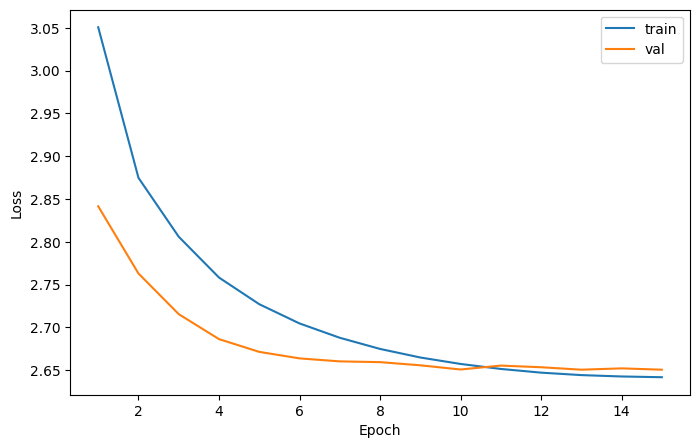

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

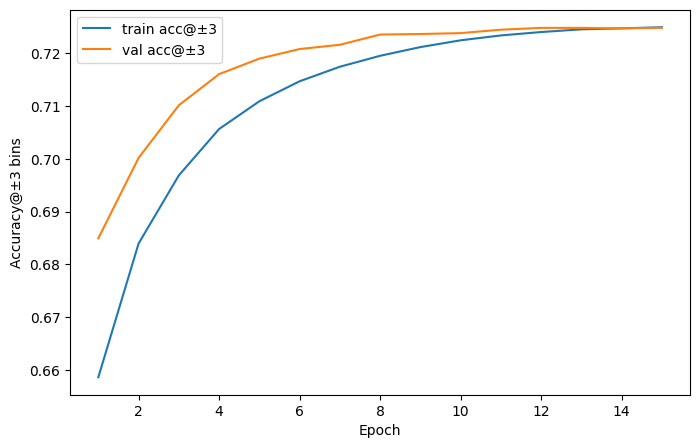

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc_pm3"], label="train acc@±3")
plt.plot(history_df["epoch"], history_df["val_acc_pm3"], label="val acc@±3")
plt.xlabel("Epoch")
plt.ylabel("Accuracy@±3 bins")
plt.legend()
plt.show()